# **Histogram Equliazton**
---

**I(enhanced)(x,y) = (L - 1) * sum(0 to I(x,y))**

In [16]:
import matplotlib.pyplot as plt

In [17]:
matrix = [[52,55,61,59],
     [62,59,55,90],
     [63,59,55,90],
     [62,59,55,90]]

In [18]:
#flatten img
flattened = [pixel for row in matrix for pixel in row]
total_pixels = len(flattened)

In [19]:
#2. Calculate Histogram (Frequency)
#Create a frequency map (dictionary) for every intensity value present.
hist = {}
for pixel in flattened:
    hist[pixel] = hist.get(pixel, 0) + 1

In [20]:
#3. Calculate Cumulative Frequency (CDF)
#Sort the intensities and find the running total of their frequencies.
sorted_intensities = sorted(hist.keys())
cdf = {}
running_sum = 0

for i in sorted_intensities:
    running_sum += hist[i]
    cdf[i] = running_sum

In [21]:
#4. Create the Transformation MapNormalize the CDF values to the standard pixel range ($0-255$).The formula used is: $h(v) = \text{round}\left(\frac{cdf(v) - cdf_{min}}{total\_pixels - cdf_{min}} \times 255\right)$Python
cdf_min = min(cdf.values())
transform_map = {}

for i in sorted_intensities:
    # Normalized scaling formula
    numerator = cdf[i] - cdf_min
    denominator = total_pixels - cdf_min
    
    if denominator == 0:
        transform_map[i] = 0
    else:
        transform_map[i] = round((numerator / denominator) * 255)

In [22]:
#5. Map the New Values
#Apply the transformation back to the original 2D matrix structure.
equalized_matrix = []
for row in matrix:
    new_row = [transform_map[pixel] for pixel in row]
    equalized_matrix.append(new_row)

print(equalized_matrix)

[[0, 68, 153, 136], [187, 136, 68, 255], [204, 136, 68, 255], [187, 136, 68, 255]]


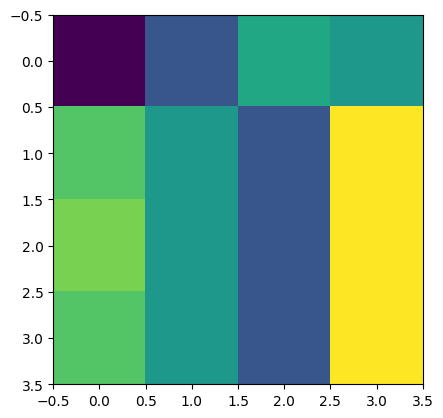

In [23]:
plt.imshow(equalized_matrix)

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
img = cv2.imread(r"C:\BDA\digital image processing\Dip_class\dip_img\images_butterfly.jfif")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [26]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

In [27]:
def hist_equalize(channel):
    rows, cols = channel.shape
    total = rows * cols

    hist = np.zeros(256)
    for i in range(rows):
        for j in range(cols):
            hist[channel[i, j]] += 1

    pdf = hist / total
    cdf = np.zeros(256)
    cdf[0] = pdf[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + pdf[i]

    eq_channel = np.zeros_like(channel)
    for i in range(rows):
        for j in range(cols):
            eq_channel[i, j] = int(255 * cdf[channel[i, j]])

    return eq_channel

In [28]:
V_eq = hist_equalize(V)

In [29]:
hsv_eq = np.stack((H, S, V_eq), axis=2)
img_eq = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB)

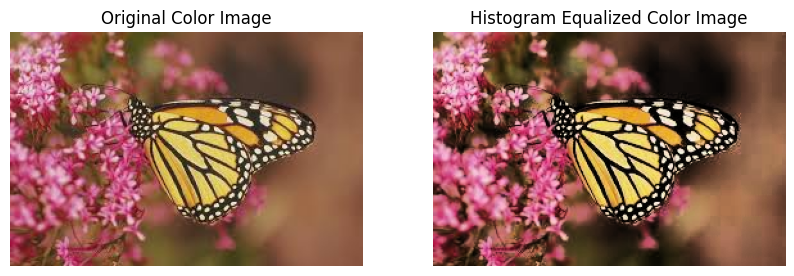

In [30]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Color Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Histogram Equalized Color Image")
plt.imshow(img_eq)
plt.axis("off")

plt.show()
